In [1]:
import numpy as np
import beyond21.global_wrapper as gw

##  Create GlobalWrapper Objects
Create a Beyond21 object using 
**`beyond21.global_wrapper.GlobalWrapper(...)`**

which takes **four parameter dictionaries**:

- `cosmo_params` *(dict, default = None)* 
- `star_formation_params` *(dict)*  
- `xray_params` *(dict)*  
- `reion_params` *(dict)*  

-Only the cosmo_params can be skipped in which case Planck18 cosmology and a ST HMF will be assumed.  
  -By default Beyond21 uses the Lyman-band spectra for PopII/PopIII provided in beyond21/data/uv_spectra 

  
---

Additional Optional Parameters:

- `lya_heat` *(bool, default = False)*  
  Set to **True** to include heating by **Lyman-alpha photons**
- `cmb_heat` *(bool, default = False)*  
  Set to **True** to include heating by **CMB**
- `photoheat` *(bool, default = False)*  
  Set to **True** to include photoheating feedback on Pop-III star formation

---
**PopIII stars** are activated by setting **star_formation_params['model'] == 'PopII+PopIII'**.  
  To run the example with PopIII change this and uncomment all PopIII parameters


 
  



In [2]:
# Set cosmological and astrophysical parameters
# - - - - - - - - - - - - - - - - - - - - - - - 

cosmo_params = {
    'Om0' : 0.3111,
    'Ob0' : 0.0490,
    'H0' : 67.66,
    'sigma8' : 0.8102,
    'ns' : 0.9665,
    'Neff' : 3.046,
    'Y_He' : 0.24, 
    'hmf_kwargs' : {"mdef": "fof", "model": "sheth99"}
    }

star_formation_params = {
                'model' : 'PopII',   # To turn on PopIII, change to 'PopII+PopIII' and uncomment the PopIII parameters below.
                'M_cutII' : 2.7e7,
                'eps_t' : 0.38,
                'F_starII' : 1.2,
                'Mpivot' : 1.3e13,
                'alphaII' : -0.46,
                'betaII' : 0.6,
                # 'F_starIII' : 5.4e-3,
                # 'alphaIII' : -0.62,
                # 'M_cutIII' : 2.5e6,
                'A_LW' : 2,
                'B_LW' : 0.6,
                'A_vrel' : 1,
                'B_vrel' : 1.8
                }

xray_params = {
    'LSFRII' : 10**(40.5),
#    'LSFRIII' : 10**(40.5),
    'E_min' : 0.5,
    'E_max' : 15,
    'alpha_s' : 1,
    'alpha_h' : 2.2,
    'E_break' : 2,
    }

reion_params = {
    'F_escII' : 2.5e-2,
    'alpha_escII' : -0.83,
    'N_ionII' : 5000,   
 #   'F_escIII' : 3.5e-3,
 #   'alpha_escIII' : -0.8,
 #   'N_ionIII' : 44000
}


# Initialize the global object and compute astrophysics history
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
GlobalObj = gw.GlobalWrapper(cosmo_params = cosmo_params, star_formation_params = star_formation_params, xray_params = xray_params, reion_params = reion_params,  Lya_Heat = False, CMB_Heat = False, photoheat = True)



## Run IGM Evolution

To compute IGM properties run  **`GlobalWrapper.EvolveSM(...)`**

This function accepts up to **four optional arguments**:

- `z_min` *(float, default = 6)*  
  Minimum redshift at which the evolution ends. Very small values may cause errors for extreme models.

- `z_max` *(float, default = 1200)*  
  Redshift at which the evolution begins. Must be greater than 1200.

- `Npoints` *(int, default = 250)*  
  Number of output points, sampled uniformly in the logarithm of the scale factor:  
  `np.linspace(np.log(1 / (1 + z_max)), np.log(1 / (1 + z_min)), Npoints)`

- `ivp_kwarges` *(dict, default = {"rtol":1e-4,"max_step":0.01})*  
  kwargs for solve_ivp  


In [3]:
# Run IGM evolution from z = 1200 to z = 6
# - - - - - - - - - - - - - - - - - - - - -
GlobalObj.EvolveIGM(z_min = 6, z_max = 1200, Nz = 250, ivp_kwargs = {"rtol":1e-4,"max_step":0.01})


<h1 style="text-align: center;"> Output Data and Plotting</h1>


<h2 style="text-align: center;">Part A - IGM evolution and 21-cm signal</h2>


After running EvolveIGM the following quantities are avialable directly

In [4]:
rs = GlobalObj.rs            # Array of redshift values (1 + z)

# Temperatures
T21 = GlobalObj.T21          # T21 signal in Kelvin
Tbaryon = GlobalObj.Tbaryon  # baryon temperature in Kelvin
Tspin = GlobalObj.Tspin      # spin temperature in Kelvin
TCMB = GlobalObj.TCMB        # CMB temperature in Kelvin

# Hydrogen ionization
xHI = GlobalObj.xHI          # neutral hydrogen fraction
tau = GlobalObj.tau          # CMB optical depth to reionization

## Built in Plotting Functions

You can also visualize the above quantities directly using the built-in plotting
functions, without accessing the underlying data arrays.

All plotting functions follow a consistent interface and accept two optional arguments:

- `axis` (matplotlib axis, optional)  
  Existing matplotlib axis to plot on. If not provided, a new figure and axis
  will be created automatically.

- `**plot_kwargs` (optional)  
  Keyword arguments passed to axis.plot() (e.g., linewidth, linestyle,
  color, etc.), allowing full customization of the plot appearance.

### Global 21-cm evolution

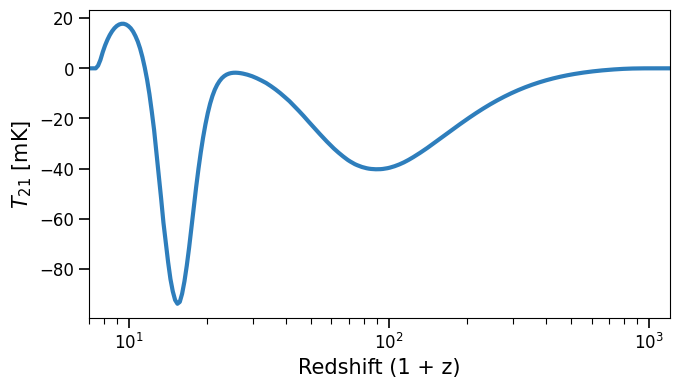

In [5]:
# (Optional) Customize plot appearance using standard matplotlib keyword arguments passed to ax.plot
plot_kwargs = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 3}

# Running plotting function
fig,ax = GlobalObj.plot_T21()

#(Optional) Further customize the axes using standard matplotlib commands
# ax.set_xlim(7,30)
# ax.set_ylim(-100,40)
# ax.set_xscale('linear')

### Combined evolution: baryon (Kinetic), hydrogen spin, and CMB temperatures

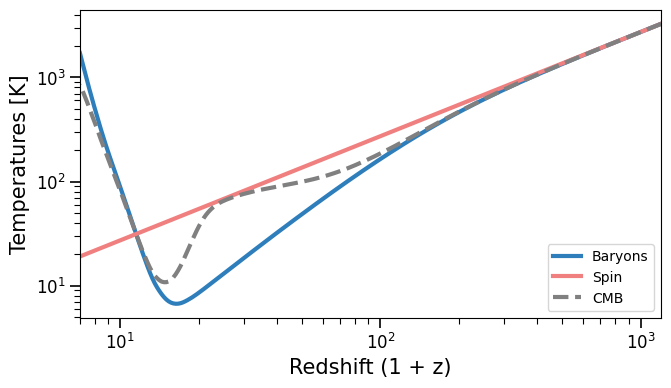

In [6]:
# Baryon Temperature Plotting function
plot_kwargs = {'label' : 'Baryons'}
fig,ax = GlobalObj.plot_Tbaryon(**plot_kwargs)

# CMB Temperature Plotting function - Plot on the same axis
plot_kwargs = {'label' : 'Spin', 'color' : 'lightcoral'}
GlobalObj.plot_TCMB(axis = ax, **plot_kwargs)

# Spin Temperature Plotting function - Plot on the same axis
plot_kwargs = {'label' : 'CMB', 'color' : 'grey', 'linestyle' : 'dashed'}
GlobalObj.plot_Tspin(axis = ax, **plot_kwargs)

# Style axis
ax.set_ylabel('Temperatures [K]')
ax.legend()

### Neutral Hydrogen Fraction Evolution

Text(7.2, 0.95, '$\\tau_{\\rm e} = 0.052$')

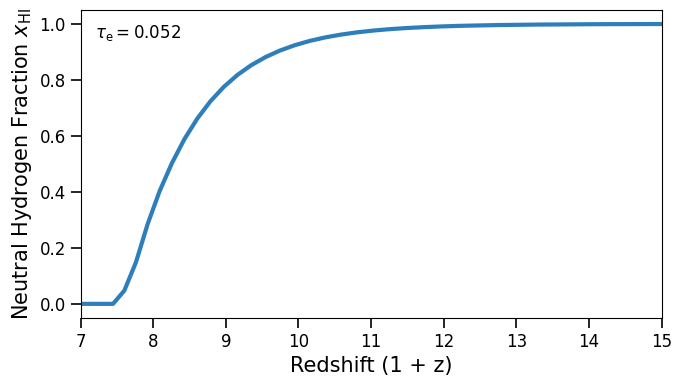

In [7]:
# Running plotting function
fig,ax = GlobalObj.plot_xHI()

# style axis
ax.set_xscale('linear')
ax.set_xlim(7,15)

# Display the optical depth to reionization on the plot
ax.text(7.2, 0.95, rf'$\tau_{{\rm e}} = {tau:.3f}$', fontsize=12)

#

<h2 align="center">Part B: Star Formation and UVLFs</h2>

### Star Formation Rate Density (SFRD)

The SFRD at a given redshift `z` is accessed through the method **`GlobalWrapper.SFRD(z)`**

which returns interpolated values in units of $\left[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{Mpc}^{-3}\right]$.

**Notes**

- If two stellar populations are modeled, the method returns an array containing
  the individual contributions from Pop II and Pop III stars:
  $[\,\mathrm{SFRD}_{\mathrm{II}}(z),\,\mathrm{SFRD}_{\mathrm{III}}(z)\,]$.

- The SFRD is only defined for redshifts $z < z_\star$, where the default value
  is $z_\star = 50$.

In [8]:
SFRD = GlobalObj.SFRD(10)

There is also a dedicated SFRD plotting function

(1e-08, 0.1)

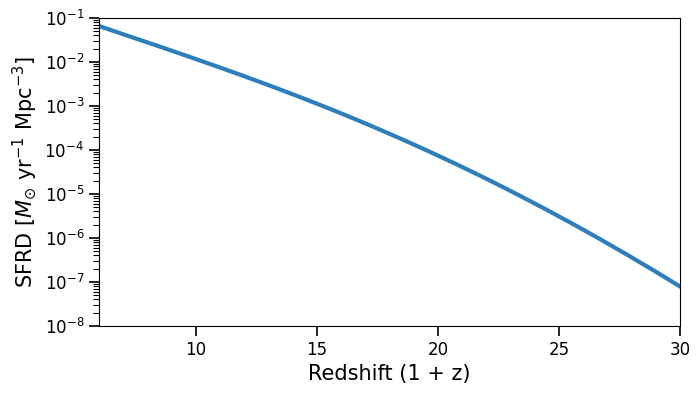

In [9]:
fig, ax = GlobalObj.plot_SFRD()

ax.set_xlim(6,30)
ax.set_ylim(1e-8,1e-1)
#ax.legend()

### UV Luminosity Function (UVLF)

Compute the UVLF at a given redshift and UV magnitude using:

**`GlobalWrapper.UVLF(z, Muv, sigma_MUV, Mh=None, kUVII=1.15e-28, kUVIII=1.15e-28)`**

which takes the following parameters:

- `z` *(float)*  
  Redshift at which the UV luminosity function is evaluated.

- `Muv` *(float or array)*  
  Absolute UV magnitude at which the UVLF is computed.

- `sigma_MUV` *(float)*  
  Log-normal scatter in the halo mass–UV magnitude relation.

---

**Optional parameters**

- `Mh` *(array-like, default = None)*  
  Custom halo mass grid used for the UVLF integration.  

- `kUVII` *(float, default = 1.15e-28)*  
  Conversion factor between SFR and UV luminosity for **Pop II** stars.

- `kUVIII` *(float, default = 1.15e-28)*  
  Conversion factor between SFR and UV luminosity for **Pop III** stars.

---

**Returns**
  UV luminosity function $\Phi(z, M_{\rm uv})$ in units of **Mag⁻¹ Mpc⁻³**.

- If **Pop II + Pop III** is set, returns a tuple [$\Phi^{\rm II}$, $\Phi^{\rm III}$]

There is also a dedicated UVLF plotting function

(1e-05, 10)

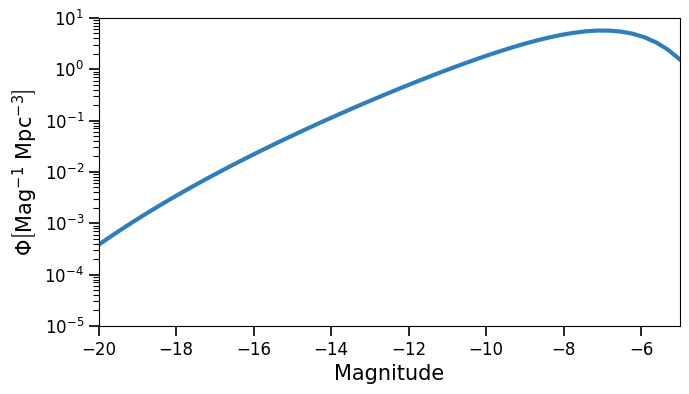

In [10]:
fig,ax = GlobalObj.plot_UVLF(7, MagArr = np.linspace(-20,-5, 50), sigma_MUV = 0.01, kUVII=1.15e-28, kUVIII=1.15e-28)
ax.set_ylim(1e-5,10)
#ax.legend()

<h2 style="text-align: center;">Part C: Radiation Backgrounds</h2>


### Cosmic X-ray Background (CXB)

Compute the contribution to the cosmic X-ray background (CXB) in an observed energy band using:

**`GlobalWrapper.CXB(zX, Emin, Emax, attenuate=False, NH=1e20, fmol=0.2)`**

which takes the following parameters:

- `zX` *(float)*  
  Minimum source redshift. Only emission from **z > zX** contributes to the CXB.

- `Emin`, `Emax` *(float)*  
  Lower and upper bounds of the observed energy band **[keV]**.

---

**Optional parameters**

- `attenuate` *(bool, default = False)*  
  Set to **True** to include attenuation by the **IGM and Milky Way absorption**. 

- `NH` *(float, default = 1e20)*  
  Hydrogen column density of the Milky Way **[cm⁻²]** used for ISM absorption.

- `fmol` *(float, default = 0.2)*  
  Molecular hydrogen fraction used in the Milky Way absorption model.

**Returns**

CXB intensity in units of **erg cm⁻² s⁻¹ sr⁻¹**.

In [11]:
GlobalObj.CXB(6,0.5,2)

2.3267072641938706e-14

### LW intensity

The LW intensity as a function of redshift is accessed through the method **`GlobalWrapper.JLW(z)`**

which returns interpolated values of the LW intensity in units of $[10^{-21} \ \rm erg \ Hz^{-1} \ cm^{-2} \ s^{-1} \ sr^{-1}]$.


In [12]:
GlobalObj.JLW(10)

2.2228542701793232

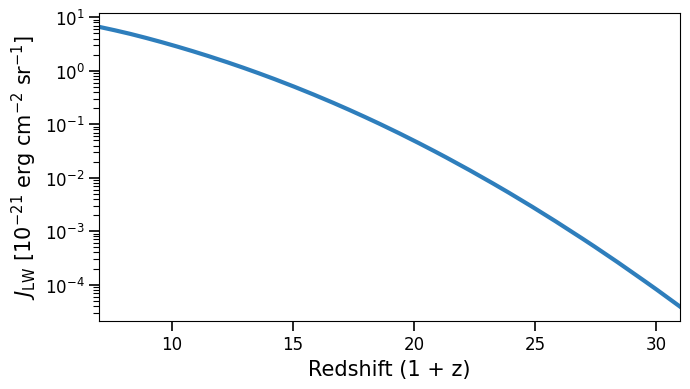

In [13]:
fig,ax = GlobalObj.plot_JLW()

### Ly-$\alpha$ intensity

The Ly-$\alpha$ intensity as a function of redshift is directly available through **`GlobalWrapper.Jalpha`** 
for redshifts (1+z) in **`GlobalWrapper.rs`** . 

Values are in $[ \rm Hz^{-1} \ cm^{-2} \ s^{-1} \ sr^{-1}]$. 


(1e-12, 1e-08)

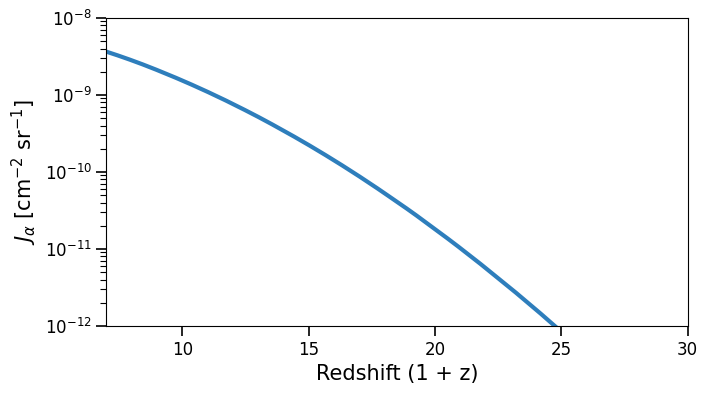

In [14]:
fig,ax = GlobalObj.plot_Jalpha()
ax.set_xlim(7,30)
ax.set_ylim(1e-12,1e-8)